# 19.3) Base Plano de Saúde 

## Regressão com Redes Neurais => Base Plano Saúde. 

In [2]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

base_plano_saude2 = pd.read_csv('plano_saude2.csv')
display(base_plano_saude2)


,idade,custo
0,18,470
1,23,520
2,28,630
3,33,830
4,38,1150
5,43,1530
6,48,2040
7,53,3080
8,58,5100
9,63,10100


In [3]:
X_plano_saude2 = base_plano_saude2.iloc[:, 0:1].values #o x recebe os dados da idade
y_plano_saude2 = base_plano_saude2.iloc[:, 1].values # o y que desejamos prever é o do custo

In [4]:
X_plano_saude2 # atributo preditor, que é a idade.

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [5]:
y_plano_saude2 # respectivos preços. 

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [6]:
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # método para padronizar ou normalizar os dados com a média e o desvio padrão. 
X_plano_saude2_scaled = scaler_x.fit_transform(X_plano_saude2)
scaler_y = StandardScaler() # método para padronizar ou normalizar os dados com a média e o desvio padrão. 
y_plano_saude2_scaled = scaler_y.fit_transform(y_plano_saude2.reshape(-1,1)) 
# estava em formato de vetor e temos que transformar em matriz.

In [9]:
# dados escalonados também exigidos nas Redes Neurais.

In [7]:
X_plano_saude2_scaled

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828],
       [ 1.21854359],
       [ 1.5666989 ]])

In [8]:
y_plano_saude2_scaled

array([[-0.72401136],
       [-0.7065653 ],
       [-0.66818397],
       [-0.59839975],
       [-0.48674498],
       [-0.35415495],
       [-0.17620517],
       [ 0.18667281],
       [ 0.8914935 ],
       [ 2.63609918]])

In [10]:
from sklearn.neural_network import MLPRegressor # ML para regressão da rede neural
regressor_rna_saude = MLPRegressor()
regressor_rna_saude.fit(X_plano_saude2_scaled, y_plano_saude2_scaled.ravel()) # treinar 
# ravel para transformar em  uma dimensção, pois é matriz e preciso que seja vetor os dados do y.

/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor()

In [12]:
# o modelo chegou ao nivel máximo de interações, no caso 200.
# E pelo aviso nem chegou a fazer todas as otimizações;

In [11]:
regressor_rna_saude.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 200,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

In [13]:
from sklearn.neural_network import MLPRegressor # ML para regressão da rede neural ao invés do classificador
regressor_rna_saude = MLPRegressor(max_iter=1000) # sinal para aumentar a quantidade de interações
regressor_rna_saude.fit(X_plano_saude2_scaled, y_plano_saude2_scaled.ravel()) # treinar

MLPRegressor(max_iter=1000)

In [14]:
regressor_rna_saude.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 1000,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

In [15]:
regressor_rna_saude.score(X_plano_saude2_scaled, y_plano_saude2_scaled)

0.9475030744099825

In [16]:
qualidade_algoritmo = regressor_rna_saude.score(X_plano_saude2_scaled, y_plano_saude2_scaled)

print('A acurácia do modelo Redes neurais com regressão é de {:.0f}%.'.format(qualidade_algoritmo*100)) 
# quanto mais perto de 1, melhor é esse valor.

A acurácia do modelo Redes neurais com regressão é de 95%.


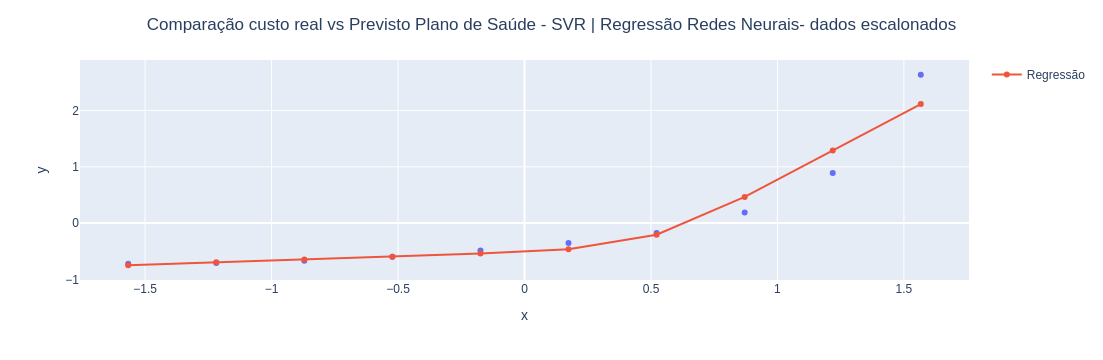

In [20]:

grafico = px.scatter(x = X_plano_saude2_scaled.ravel(), y = y_plano_saude2_scaled.ravel())
grafico.add_scatter(x = X_plano_saude2_scaled.ravel(), y = regressor_rna_saude.predict(X_plano_saude2_scaled), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - SVR | Regressão Redes Neurais- dados escalonados',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_6.html")  # valor real o azul, previsto o vermelho regressão

In [19]:
# redes neurais conseguem se adaptar bem aos dados.

In [21]:
novo = [[40]] # idade de 40 anos, escalonar
novo = scaler_x.transform(novo)
novo

array([[-0.03481553]])

In [22]:
##scaler_y.inverse_transform(regressor_rna_saude.predict(novo)) -- Atualizado 17/08/2022 -- Inclusão .reshape(-1, 1)

In [23]:
regressor_rna_saude.predict(novo)

array([-0.51838501])

In [25]:
# forma correta
scaler_y.inverse_transform(regressor_rna_saude.predict(novo).reshape(-1, 1)) # invertermos osados escalonados para a forma original

array([[1059.32040314]])

In [27]:
corretoPrevistoy= scaler_y.inverse_transform(regressor_rna_saude.predict(X_plano_saude2_scaled).reshape(-1, 1))

In [28]:
corretoPrevistoy

array([[ 399.33915294],
       [ 546.99117195],
       [ 694.01234464],
       [ 829.06424782],
       [ 991.68095519],
       [1219.09365271],
       [1953.16054343],
       [3878.6726942 ],
       [6243.01131077],
       [8607.1624446 ]])

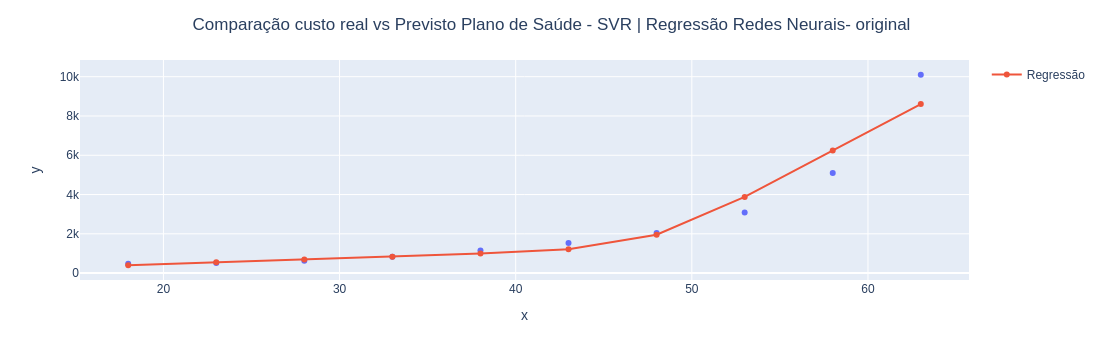

In [35]:

grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2.ravel())
grafico.add_scatter(x = X_plano_saude2.ravel(), y = corretoPrevistoy.ravel(), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - SVR | Regressão Redes Neurais- original',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_7.html")  # valor real o azul, previsto o vermelho regressão